# Exploratory Image Analysis

This notebook inspects the prepared CelebA dataset before model training (1000 images)

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.utils.paths import load_config, ensure_dir

In [2]:
config = load_config(PROJECT_ROOT / "config.yaml")

manifest_path = PROJECT_ROOT / "data" / "interim" / "celeba_manifest.csv"
figures_dir = ensure_dir(PROJECT_ROOT / config["reports"]["figures_dir"])

manifest_path

WindowsPath('e:/celeba-generative-comparison/data/interim/celeba_manifest.csv')

In [7]:
df = pd.read_csv(manifest_path)

print("Manifest shape:", df.shape)
display(df.head())

Manifest shape: (1000, 46)


,image_id,partition,split,raw_path,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,exists,processed_path
0,000001.jpg,0,train,data\raw\celeba\img_align_celeba\img_align_cel...,-1,1,1,-1,-1,-1,...,1,-1,1,-1,1,-1,-1,1,True,data\processed\celeba_64\train\000001.jpg
1,000002.jpg,0,train,data\raw\celeba\img_align_celeba\img_align_cel...,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,1,True,data\processed\celeba_64\train\000002.jpg
2,000003.jpg,0,train,data\raw\celeba\img_align_celeba\img_align_cel...,-1,-1,-1,-1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,1,True,data\processed\celeba_64\train\000003.jpg
3,000004.jpg,0,train,data\raw\celeba\img_align_celeba\img_align_cel...,-1,-1,1,-1,-1,-1,...,1,-1,1,-1,1,1,-1,1,True,data\processed\celeba_64\train\000004.jpg
4,000005.jpg,0,train,data\raw\celeba\img_align_celeba\img_align_cel...,-1,1,1,-1,-1,-1,...,-1,-1,-1,-1,1,-1,-1,1,True,data\processed\celeba_64\train\000005.jpg


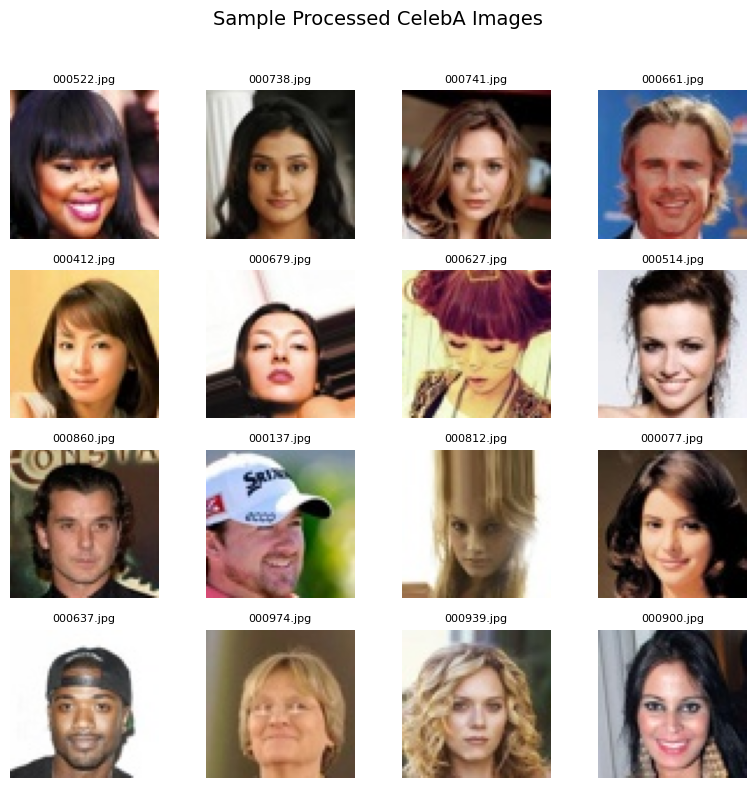

In [ ]:
sample_df = df[df["split"] == "train"].sample(
    n=min(16, len(df[df["split"] == "train"])),
    random_state=42
)

plt.figure(figsize=(8, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    image_path = PROJECT_ROOT / row["processed_path"]
    image = Image.open(image_path).convert("RGB")

    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(row["image_id"], fontsize=8)

plt.suptitle("Sample Processed CelebA Images", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

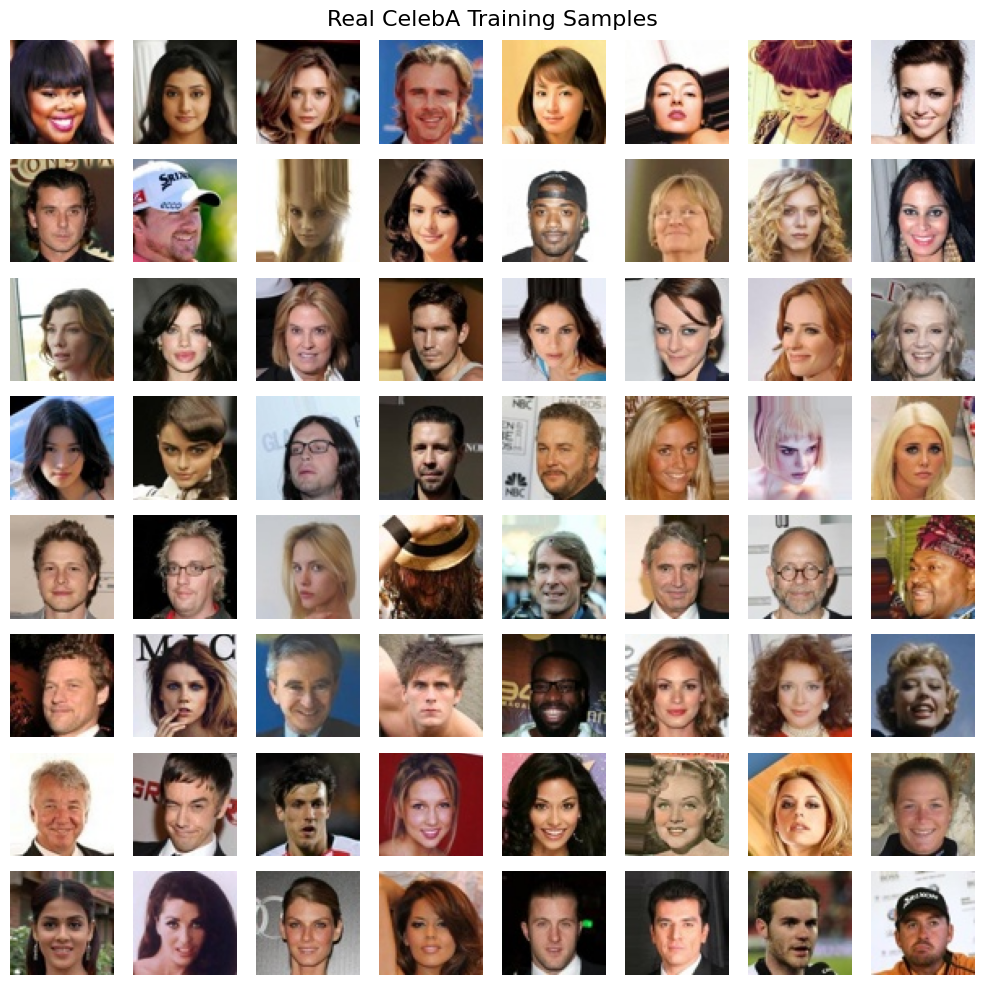

Saved to: e:\celeba-generative-comparison\reports\figures\real_samples_grid.png


In [14]:
sample_df = df[df["split"] == "train"].sample(
    n=min(64, len(df[df["split"] == "train"])),
    random_state=42
)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    image_path = PROJECT_ROOT / row["processed_path"]
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.axis("off")

plt.suptitle("Real CelebA Training Samples", fontsize=16)
plt.tight_layout()

real_grid_path = figures_dir / "real_samples_grid.png"
plt.savefig(real_grid_path, dpi=150)
plt.show()

print("Saved to:", real_grid_path)

In [15]:
non_attribute_cols = {
    "image_id",
    "partition",
    "split",
    "raw_path",
    "processed_path",
    "exists",
    "processed_exists"
}

attribute_cols = [
    col for col in df.columns
    if col not in non_attribute_cols
    and pd.api.types.is_numeric_dtype(df[col])
]

print("Number of detected attribute columns:", len(attribute_cols))
print(attribute_cols[:20])

Number of detected attribute columns: 40
['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones']


In [16]:
if len(attribute_cols) > 0:
    attr_positive_rates = {}

    for col in attribute_cols:
        # CelebA attributes are usually -1 or 1
        attr_positive_rates[col] = (df[col] == 1).mean()

    attr_df = (
        pd.DataFrame({
            "attribute": list(attr_positive_rates.keys()),
            "positive_rate": list(attr_positive_rates.values())
        })
        .sort_values("positive_rate", ascending=False)
        .reset_index(drop=True)
    )

    display(attr_df.head(20))
else:
    print("No attribute columns found.")

,attribute,positive_rate
0,No_Beard,0.827
1,Young,0.754
2,Attractive,0.520
3,Smiling,0.510
4,Mouth_Slightly_Open,0.503
5,High_Cheekbones,0.463
6,Wearing_Lipstick,0.461
7,Male,0.432
8,Heavy_Makeup,0.382
9,Wavy_Hair,0.287


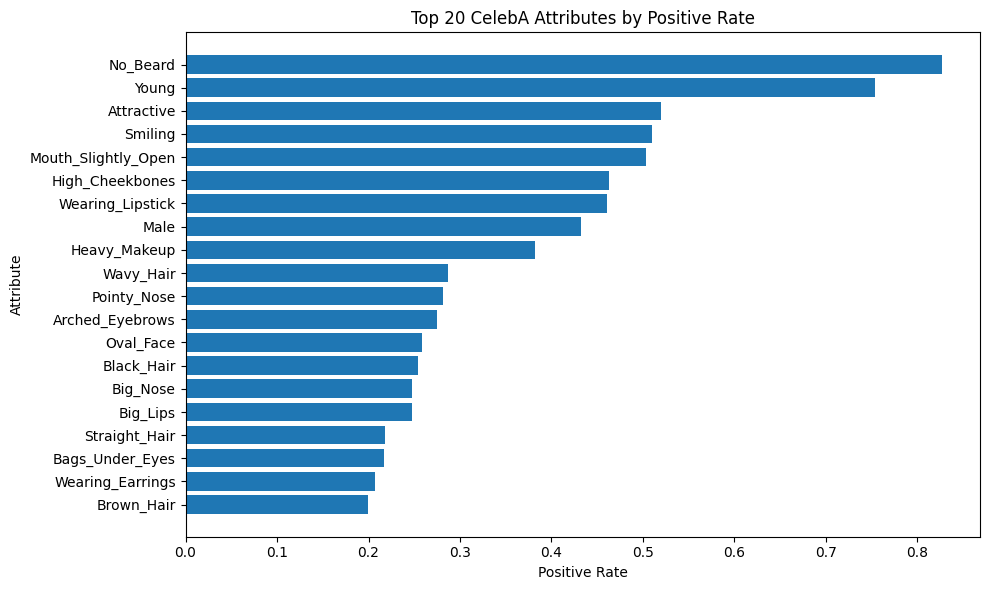

Saved to: e:\celeba-generative-comparison\reports\figures\top_attribute_distribution.png


In [17]:
if len(attribute_cols) > 0:
    top_attrs = attr_df.head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(top_attrs["attribute"], top_attrs["positive_rate"])
    plt.gca().invert_yaxis()
    plt.title("Top 20 CelebA Attributes by Positive Rate")
    plt.xlabel("Positive Rate")
    plt.ylabel("Attribute")
    plt.tight_layout()

    attr_plot_path = figures_dir / "top_attribute_distribution.png"
    plt.savefig(attr_plot_path, dpi=150)
    plt.show()

    print("Saved to:", attr_plot_path)
else:
    print("Skipping attribute plot because no attribute columns were found.")

In [19]:
sample_paths = df["processed_path"].sample(
    n=min(100, len(df)),
    random_state=42
)

sizes = []

for path in sample_paths:
    image_path = PROJECT_ROOT / row["processed_path"]
    image = Image.open(image_path).convert("RGB")
    sizes.append(image.size)

size_df = pd.DataFrame(sizes, columns=["width", "height"])

display(size_df.value_counts().reset_index(name="count"))

,width,height,count
0,64,64,100
